# 03 Exploratory Data Analysis (EDA)

Now that the data is clean, I can finally make some plots! I want to see how the total area for crops is changing over time and which states are doing the best.

### Imports and Plot Style Setup

This cell loads `pandas`, plotting tools, and formatter utilities.

It also defines a single visual theme (colors, fonts, grid behavior, chart footer) so every figure in this notebook has a consistent presentation style.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

MAIN_COLOR = "#1B365D"
MID_COLOR = "#2F5D8A"
FILL_COLOR = "#7EA6C2"
BG_COLOR = "#F9FAFB"
GRID_COLOR = "#C7D2E0"
TEXT_COLOR = "#4B5563"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def style_ax(ax, vertical_grid=True):
    ax.set_facecolor(BG_COLOR)
    if vertical_grid:
        ax.grid(axis="y", linestyle="--", linewidth=1, alpha=0.5, color=GRID_COLOR)
    else:
        ax.grid(axis="x", linestyle="--", linewidth=1, alpha=0.5, color=GRID_COLOR)


def add_footer(ax):
    ax.text(
        0.0,
        -0.18,
        "Source: India APY dataset | Reporting window: 2011-2019",
        transform=ax.transAxes,
        fontsize=10,
        color=TEXT_COLOR,
        ha="left"
    )

### Load Cleaned Dataset

Read the cleaned dataset from `../data/processed/cleaned_data.csv`.

All EDA plots below use this cleaned table, not the raw extraction file.

In [93]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

### Trend 1: National Production Over Time

Group by `year` and sum `production` to get national annual output.

The line and filled area are used to highlight long-term production direction and year-to-year changes.

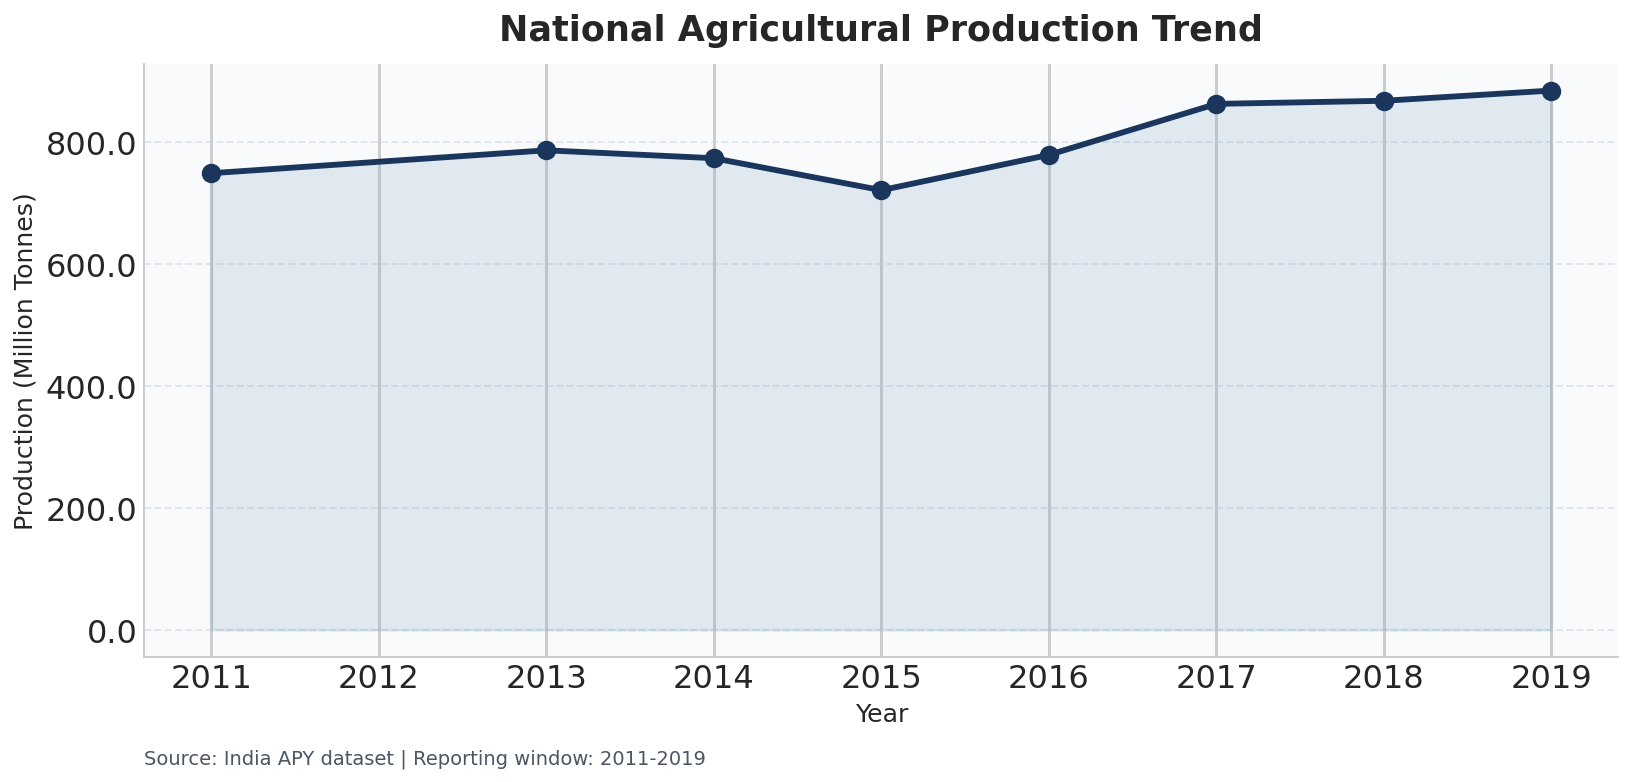

In [94]:
prod_trend = df.groupby("year")["production"].sum()

fig, ax = plt.subplots()
ax.plot(prod_trend.index, prod_trend.values, color=MAIN_COLOR, marker="o", linewidth=3)
ax.fill_between(prod_trend.index, prod_trend.values, color=FILL_COLOR, alpha=0.20)

ax.set_title("National Agricultural Production Trend", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Production (Million Tonnes)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x / 1e6:.1f}"))

style_ax(ax, vertical_grid=True)
add_footer(ax)
plt.tight_layout()
plt.show()

### Trend 2: National Cultivated Area Over Time

Group by `year` and sum `area` to measure yearly cultivated land.

Comparing this chart with production helps interpret whether growth comes from expansion in area, better productivity, or both.

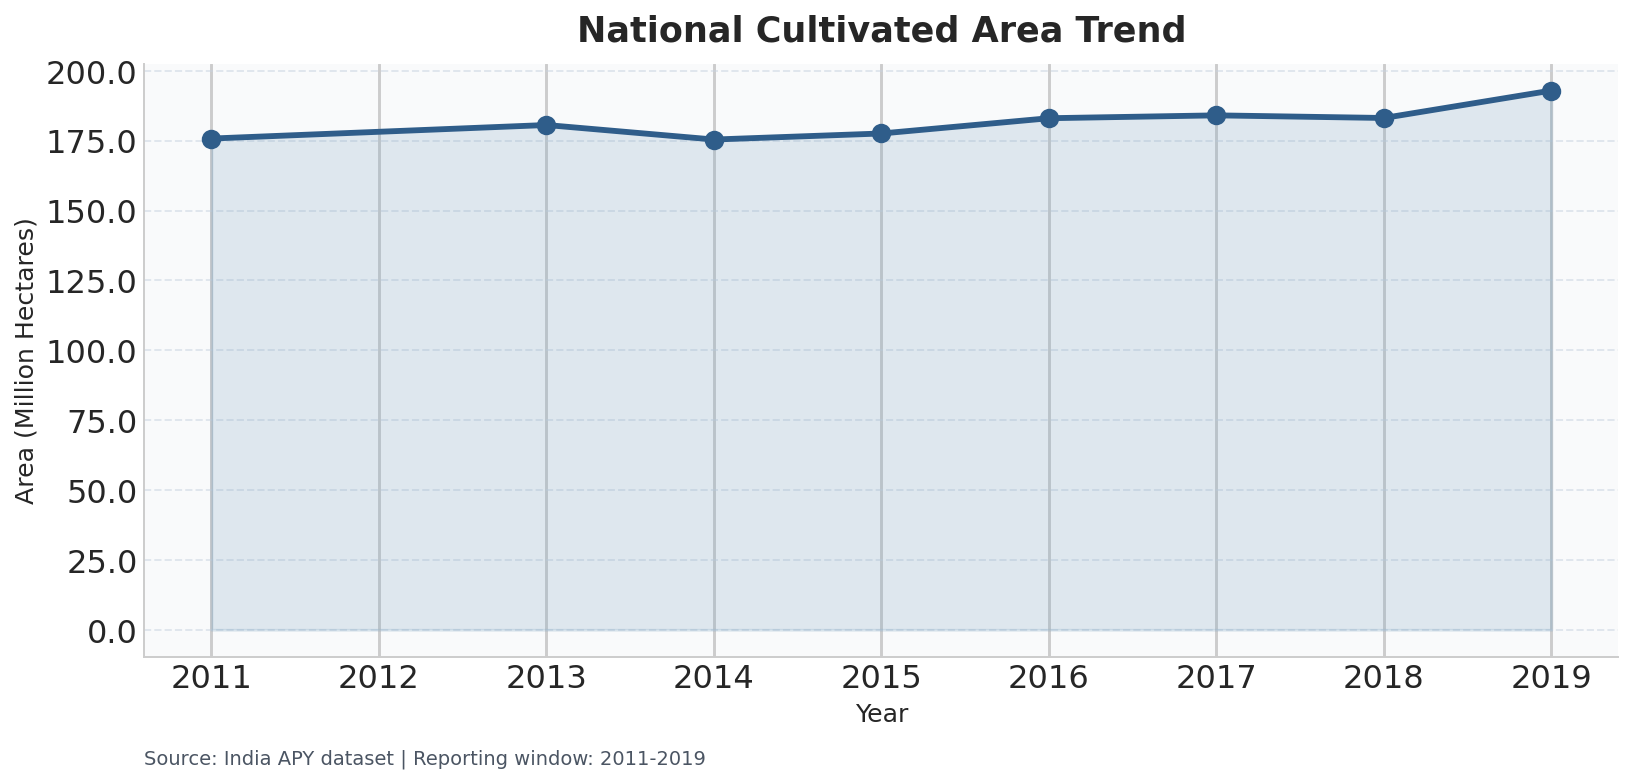

In [95]:
area_trend = df.groupby("year")["area"].sum()

fig, ax = plt.subplots()
ax.plot(area_trend.index, area_trend.values, color=MID_COLOR, marker="o", linewidth=3)
ax.fill_between(area_trend.index, area_trend.values, color=FILL_COLOR, alpha=0.22)

ax.set_title("National Cultivated Area Trend", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Area (Million Hectares)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x / 1e6:.1f}"))

style_ax(ax, vertical_grid=True)
add_footer(ax)
plt.tight_layout()
plt.show()

### Trend 3: National Weighted Average Yield

Compute annual weighted yield as total production divided by total area for each year.

This avoids simple averaging bias and gives a better national efficiency signal.

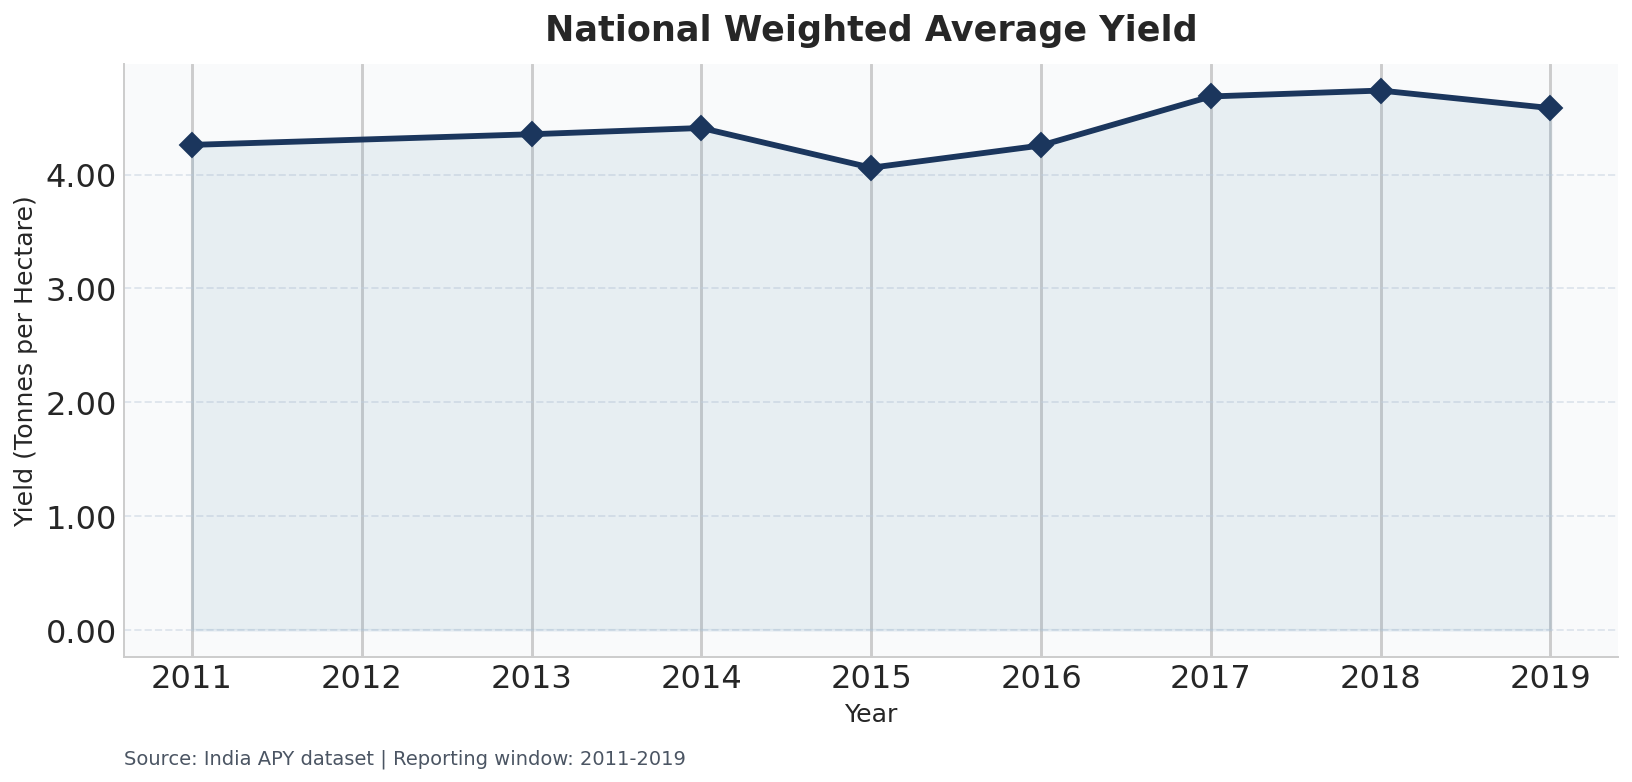

In [96]:
yield_trend = df.groupby("year").apply(
    lambda part: part["production"].sum() / part["area"].sum(),
    include_groups=False
)

fig, ax = plt.subplots()
ax.plot(yield_trend.index, yield_trend.values, color=MAIN_COLOR, marker="D", linewidth=3)
ax.fill_between(yield_trend.index, yield_trend.values, color=FILL_COLOR, alpha=0.14)

ax.set_title("National Weighted Average Yield", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Yield (Tonnes per Hectare)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:.2f}"))

style_ax(ax, vertical_grid=True)
add_footer(ax)
plt.tight_layout()
plt.show()

### Ranking 1: Top Crops by Production

Filter out coconut to keep units comparable, then aggregate total production by crop.

The top 10 crops are sorted for a horizontal ranking chart to improve label readability.

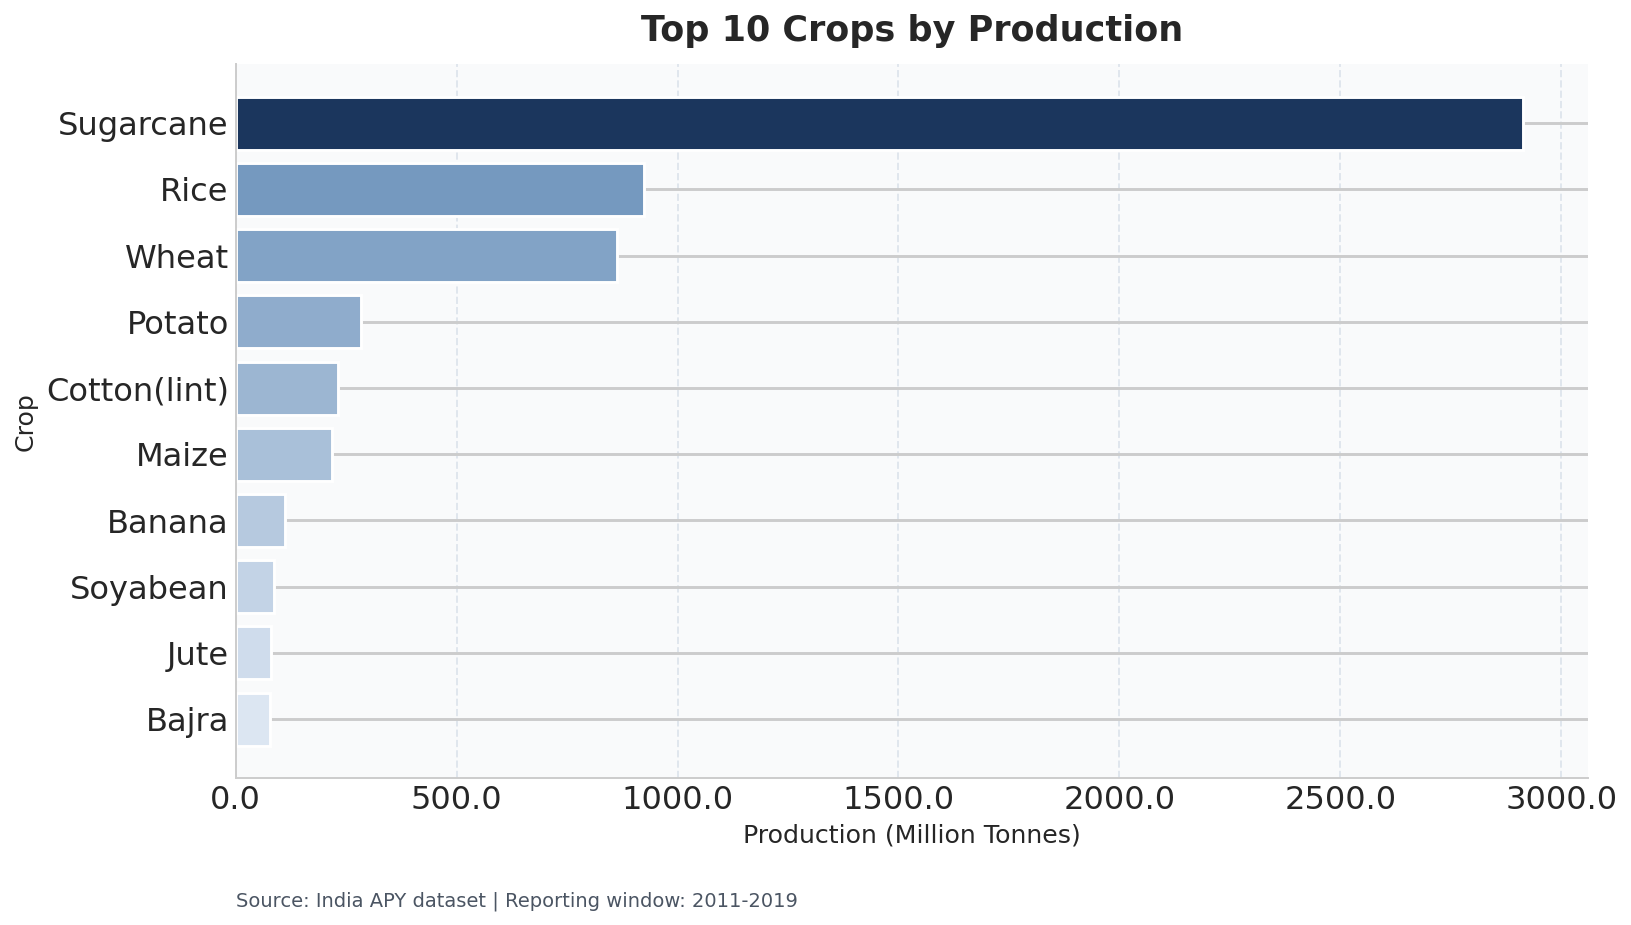

In [97]:
top_crops = (
    df[df["crop"].str.strip().str.lower() != "coconut"]
    .groupby("crop")["production"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = ["#DCE6F2", "#CFDCEC", "#C3D3E6", "#B6C9DF", "#A9C0D9", "#9CB6D2", "#8FACCC", "#82A3C6", "#7599BF", MAIN_COLOR]
ax.barh(top_crops.index, top_crops.values, color=bar_colors)

ax.set_title("Top 10 Crops by Production", pad=12)
ax.set_xlabel("Production (Million Tonnes)")
ax.set_ylabel("Crop")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x / 1e6:.1f}"))

style_ax(ax, vertical_grid=False)
add_footer(ax)
plt.tight_layout()
plt.show()

### Ranking 2: Production by Season

Aggregate production by season and sort descending.

This shows which agricultural season contributes most to national output and highlights seasonality in production patterns.

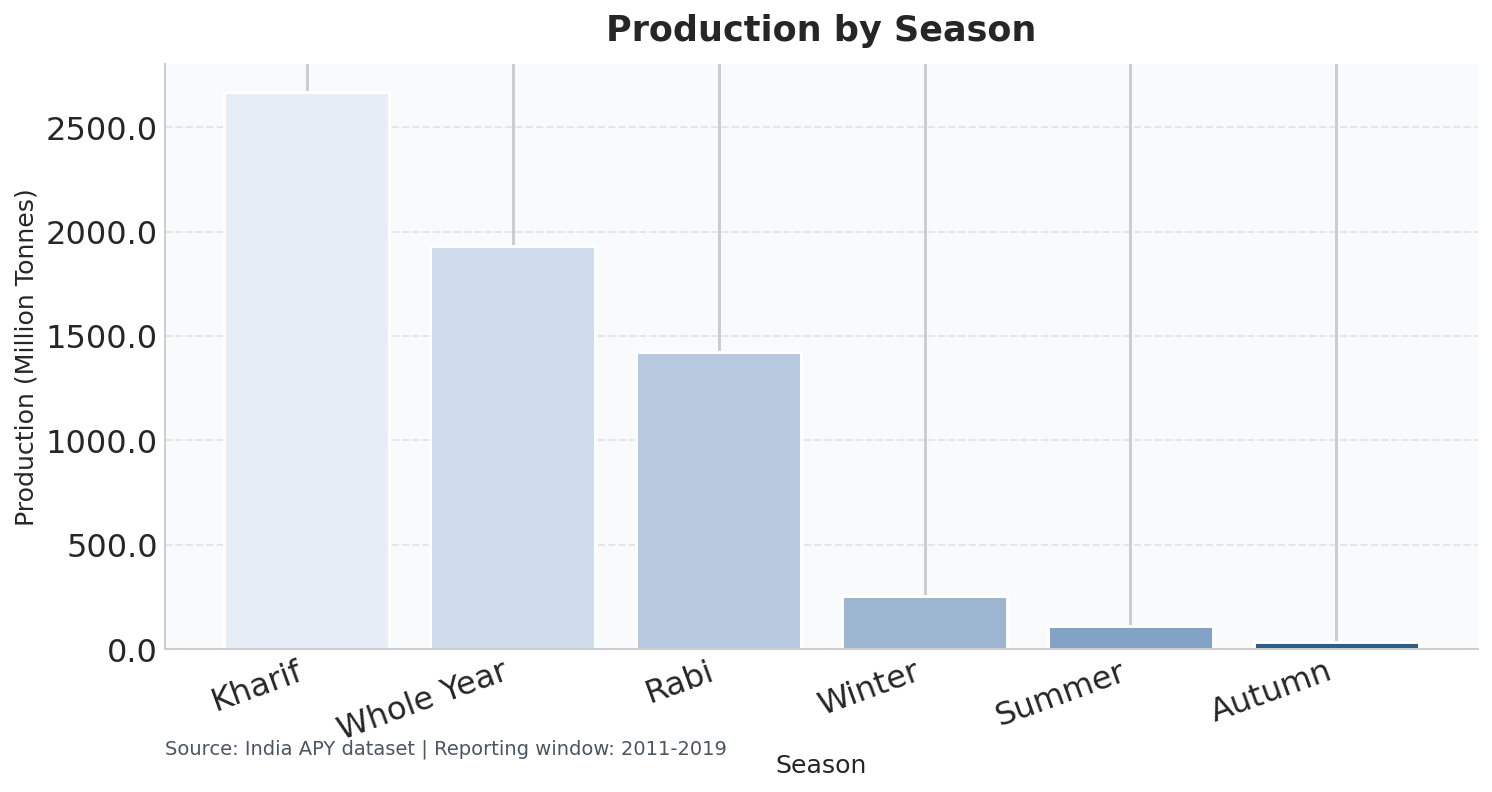

In [98]:
season_prod = df.groupby("season")["production"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ["#E6EDF7", "#CFDCEC", "#B6C9DF", "#9CB6D2", "#82A3C6", MID_COLOR]
ax.bar(season_prod.index, season_prod.values, color=bar_colors)

ax.set_title("Production by Season", pad=12)
ax.set_xlabel("Season")
ax.set_ylabel("Production (Million Tonnes)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x / 1e6:.1f}"))

style_ax(ax, vertical_grid=True)
plt.xticks(rotation=20, ha="right")
add_footer(ax)
plt.tight_layout()
plt.show()

### Ranking 3: Top States by Production

Sum production by state, select the top 10, and plot as a horizontal bar chart.

This identifies high-output states and provides geographic context for overall national trends.

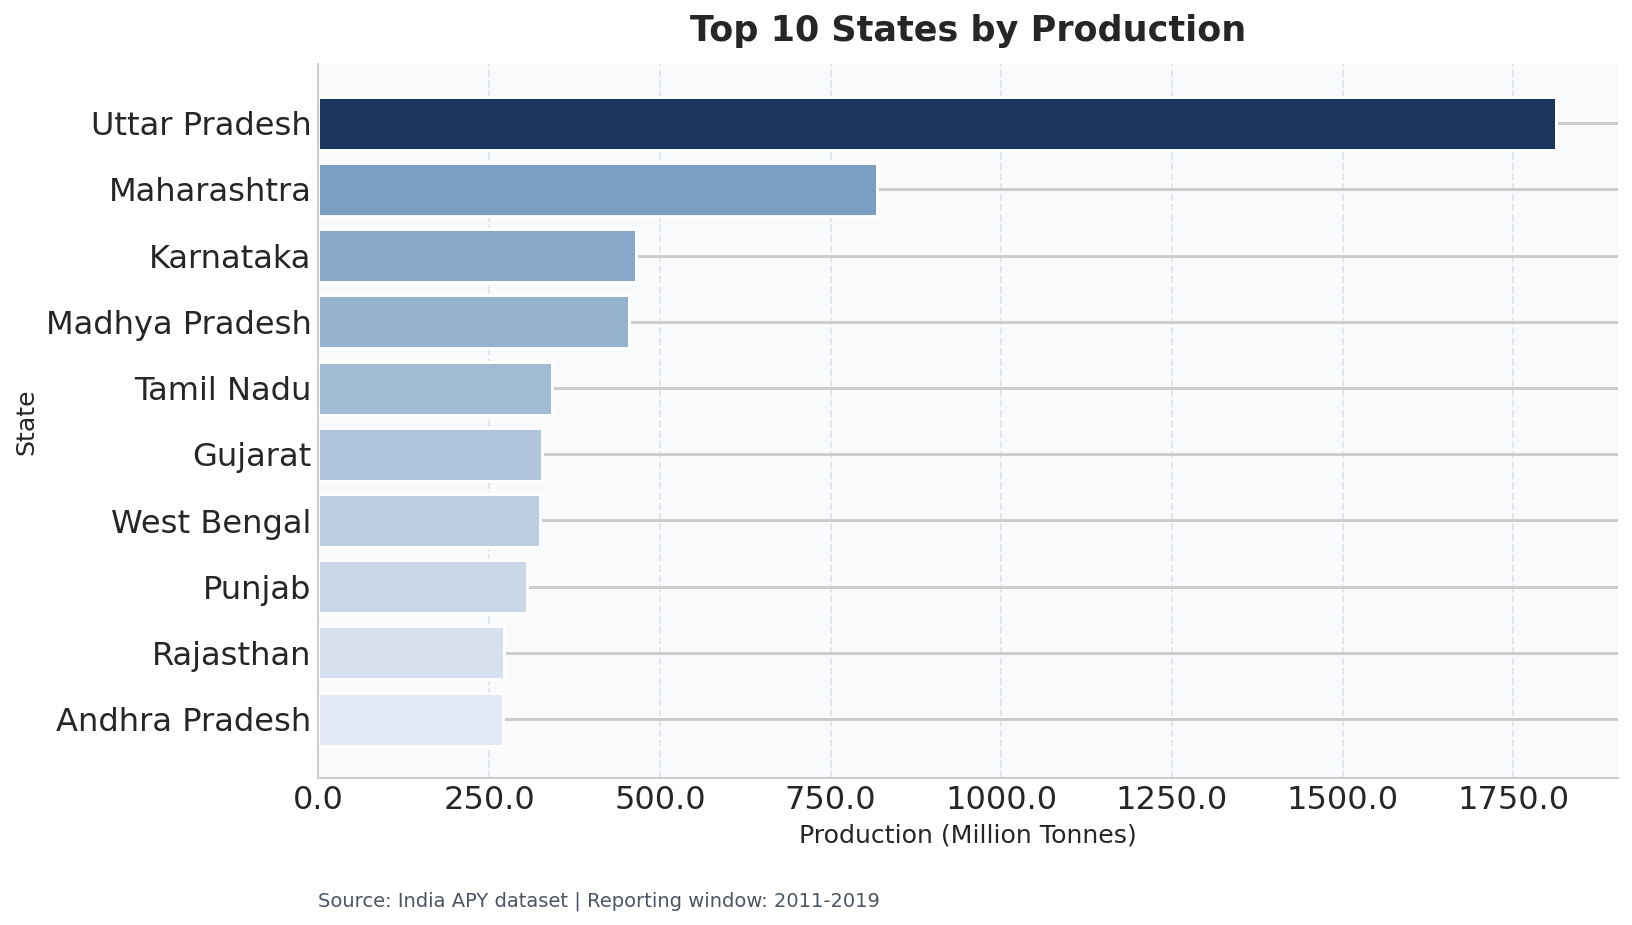

In [99]:
state_prod = (
    df.groupby("state")["production"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = ["#E2E9F4", "#D6E0EE", "#C9D7E8", "#BCCEE2", "#AFC4DB", "#A2BBD5", "#95B2CF", "#88A8C9", "#7B9FC3", MAIN_COLOR]
ax.barh(state_prod.index, state_prod.values, color=bar_colors)

ax.set_title("Top 10 States by Production", pad=12)
ax.set_xlabel("Production (Million Tonnes)")
ax.set_ylabel("State")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x / 1e6:.1f}"))

style_ax(ax, vertical_grid=False)
add_footer(ax)
plt.tight_layout()
plt.show()

### Coverage Check: States and Districts by Year

Count unique states and districts per year.

This verifies temporal coverage consistency and helps flag years with weaker geographic representation.

In [100]:
year_state_counts = df.groupby("year")["state"].nunique()
year_district_counts = df.groupby("year")["district"].nunique()

print("States per year:\n", year_state_counts)
print("\nDistricts per year:\n", year_district_counts)

States per year:
 year
2011    35
2013    35
2014    35
2015    35
2016    35
2017    35
2018    35
2019    34
Name: state, dtype: int64

Districts per year:
 year
2011    634
2013    644
2014    655
2015    657
2016    683
2017    683
2018    687
2019    695
Name: district, dtype: int64


### End of EDA Notebook

At this point, core trend and ranking visuals are complete.

Optional next step: add targeted deep-dives (for example, state-wise crop mix or crop-specific yield trends) using the same styling pattern.